In [4]:
# Bellabeat Case Study - Data Analysis in Python

# Step 1: Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns in output
pd.set_option('display.max_columns', None)

# Step 2: Load datasets
activity = pd.read_csv('../data/dailyActivity_merged.csv')
sleep = pd.read_csv('../data/sleepDay_merged.csv')

# Step 3: Preview data
print("Activity Data:")
display(activity.head())

print("Sleep Data:")
display(sleep.head())


Activity Data:


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


Sleep Data:


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [5]:
# Step 4: Check for missing values
print("Missing values in activity data:")
print(activity.isnull().sum())

print("\nMissing values in sleep data:")
print(sleep.isnull().sum())

# Step 5: Check for duplicate rows
print("\nDuplicate rows in activity:", activity.duplicated().sum())
print("Duplicate rows in sleep:", sleep.duplicated().sum())

# Step 6: Data types and structure
print("\nActivity Data Types:")
print(activity.dtypes)

print("\nSleep Data Types:")
print(sleep.dtypes)

# Step 7: Convert 'ActivityDate' and 'SleepDay' to datetime
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')

# Check again after conversion
print("\nConverted activity date type:", activity['ActivityDate'].dtype)
print("Converted sleep date type:", sleep['SleepDay'].dtype)


Missing values in activity data:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Missing values in sleep data:
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

Duplicate rows in activity: 0
Duplicate rows in sleep: 3

Activity Data Types:
Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
Moderate

In [6]:
# Remove duplicates from sleep data
sleep_clean = sleep.drop_duplicates()

# Double-check it's clean
print("Duplicates after cleaning:", sleep_clean.duplicated().sum())

# Also check the shape of both datasets
print("\nActivity data shape:", activity.shape)
print("Sleep data shape after cleaning:", sleep_clean.shape)


Duplicates after cleaning: 0

Activity data shape: (940, 15)
Sleep data shape after cleaning: (410, 5)


In [7]:
# Summary statistics for activity data
print("Activity Summary:")
display(activity.describe())

# Summary statistics for sleep data
print("\nSleep Summary:")
display(sleep_clean.describe())


Activity Summary:


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000
std,2.424805e+09,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862



Sleep Summary:


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.100000e+02,410,410.000000,410.000000,410.000000
mean,4.994963e+09,2016-04-26 11:38:55.609756160,1.119512,419.173171,458.482927
min,1.503960e+09,2016-04-12 00:00:00,1.000000,58.000000,61.000000
25%,3.977334e+09,2016-04-19 00:00:00,1.000000,361.000000,403.750000
50%,4.702922e+09,2016-04-27 00:00:00,1.000000,432.500000,463.000000
75%,6.962181e+09,2016-05-04 00:00:00,1.000000,490.000000,526.000000
max,8.792010e+09,2016-05-12 00:00:00,3.000000,796.000000,961.000000
std,2.060863e+09,NaN,0.346636,118.635918,127.455140


In [8]:
# Remove sleep entries with 0 time in bed or where asleep > in bed
sleep_clean = sleep_clean[(sleep_clean['TotalTimeInBed'] > 0) &
                          (sleep_clean['TotalMinutesAsleep'] <= sleep_clean['TotalTimeInBed'])]

# Remove activity entries with 0 calories (not realistic)
activity_clean = activity[activity['Calories'] > 0]

# Check shape after cleaning
print("Cleaned activity shape:", activity_clean.shape)
print("Cleaned sleep shape:", sleep_clean.shape)


Cleaned activity shape: (936, 15)
Cleaned sleep shape: (410, 5)


In [9]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    clean_df = df[(df[column] >= lower) & (df[column] <= upper)]
    print(f"{column}: Removed {df.shape[0] - clean_df.shape[0]} outliers")
    return clean_df

# Apply to activity data
activity_clean = remove_outliers_iqr(activity_clean, 'TotalSteps')
activity_clean = remove_outliers_iqr(activity_clean, 'Calories')

# Apply to sleep data
sleep_clean = remove_outliers_iqr(sleep_clean, 'TotalMinutesAsleep')
sleep_clean = remove_outliers_iqr(sleep_clean, 'TotalTimeInBed')


TotalSteps: Removed 13 outliers
Calories: Removed 11 outliers
TotalMinutesAsleep: Removed 27 outliers
TotalTimeInBed: Removed 6 outliers


In [10]:
print("Cleaned activity shape:", activity_clean.shape)
print("Cleaned sleep shape:", sleep_clean.shape)

Cleaned activity shape: (912, 15)
Cleaned sleep shape: (377, 5)


In [11]:
# First, ensure both have matching column names for the date
activity_clean['ActivityDate'] = pd.to_datetime(activity_clean['ActivityDate'])
sleep_clean['SleepDay'] = pd.to_datetime(sleep_clean['SleepDay'])

# Merge the datasets on the date
merged_df = pd.merge(activity_clean, sleep_clean, left_on='ActivityDate', right_on='SleepDay', how='inner')

# Drop duplicate date column
merged_df.drop('SleepDay', axis=1, inplace=True)

# Check merged data
print("Merged data shape:", merged_df.shape)
merged_df.head()


Merged data shape: (11187, 19)


,Id_x,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Id_y,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,1503960366,1,327,346
1,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2026352035,1,503,546
2,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,3977333714,1,274,469
3,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,4020332650,1,501,541
4,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,4445114986,2,429,457


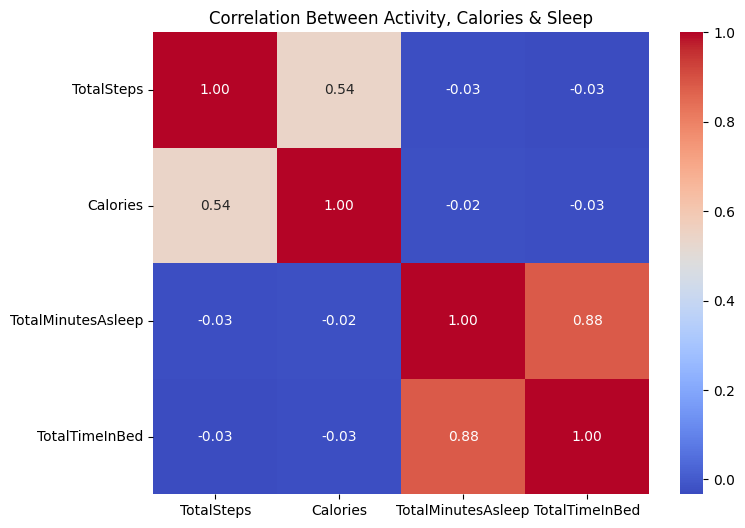

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
correlation_data = merged_df[['TotalSteps', 'Calories', 'TotalMinutesAsleep', 'TotalTimeInBed']]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Activity, Calories & Sleep')
plt.show()


In [13]:
# Create activity levels based on TotalSteps
def label_activity(steps):
    if steps < 5000:
        return 'Sedentary'
    elif 5000 <= steps < 7500:
        return 'Lightly Active'
    elif 7500 <= steps < 10000:
        return 'Moderately Active'
    else:
        return 'Very Active'

# Apply to DataFrame
merged_df['ActivityLevel'] = merged_df['TotalSteps'].apply(label_activity)

# Compare average sleep for each group
sleep_by_activity = merged_df.groupby('ActivityLevel')[['TotalMinutesAsleep', 'TotalTimeInBed']].mean().reset_index()
sleep_by_activity


,ActivityLevel,TotalMinutesAsleep,TotalTimeInBed
0,Lightly Active,429.245663,468.134552
1,Moderately Active,428.750757,466.008073
2,Sedentary,432.014550,470.639340
3,Very Active,426.467982,464.659520


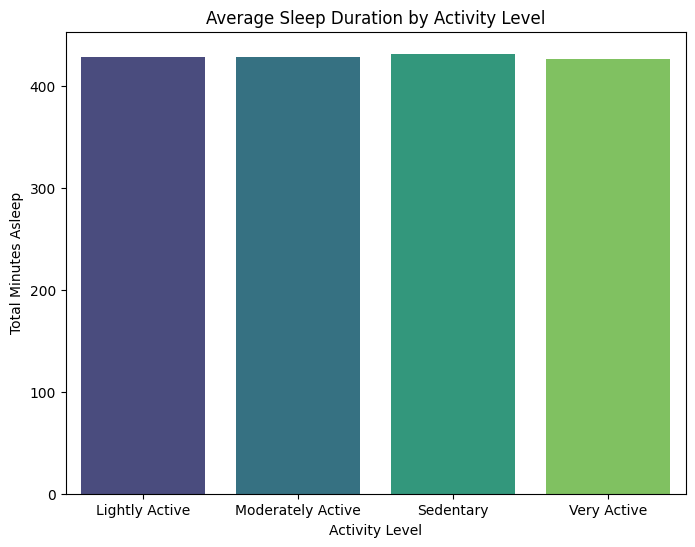

In [14]:
# Plot sleep duration by activity level
plt.figure(figsize=(8,6))
sns.barplot(data=sleep_by_activity,x='ActivityLevel',y='TotalMinutesAsleep', hue='ActivityLevel',palette='viridis',legend=False)

#sns.barplot(data=sleep_by_activity, x='ActivityLevel', y='TotalMinutesAsleep', palette='viridis')
plt.title('Average Sleep Duration by Activity Level')
plt.ylabel('Total Minutes Asleep')
plt.xlabel('Activity Level')
plt.show()


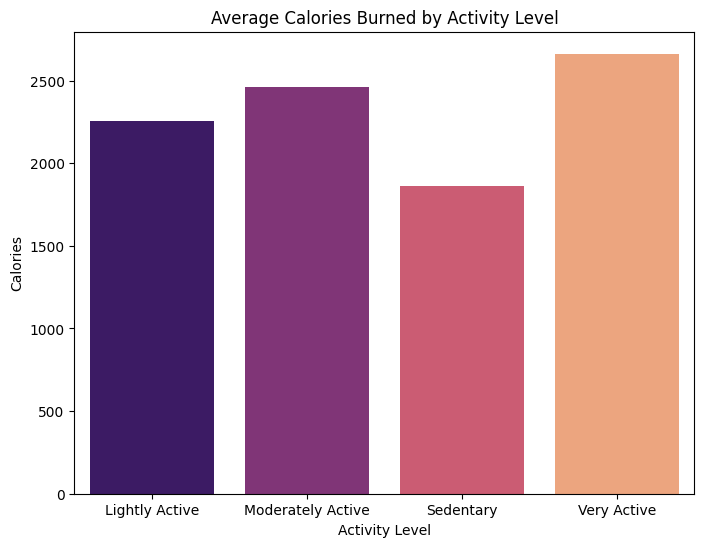

In [15]:
# Group by activity level
calories_by_activity = merged_df.groupby('ActivityLevel')['Calories'].mean().reset_index()

# Plot it
plt.figure(figsize=(8,6))
sns.barplot(data=calories_by_activity, x='ActivityLevel', y='Calories',hue='ActivityLevel', palette='magma' ,legend=False)
plt.title('Average Calories Burned by Activity Level')
plt.ylabel('Calories')
plt.xlabel('Activity Level')
plt.show()


Average Sleep Efficiency: 0.9181251440560783


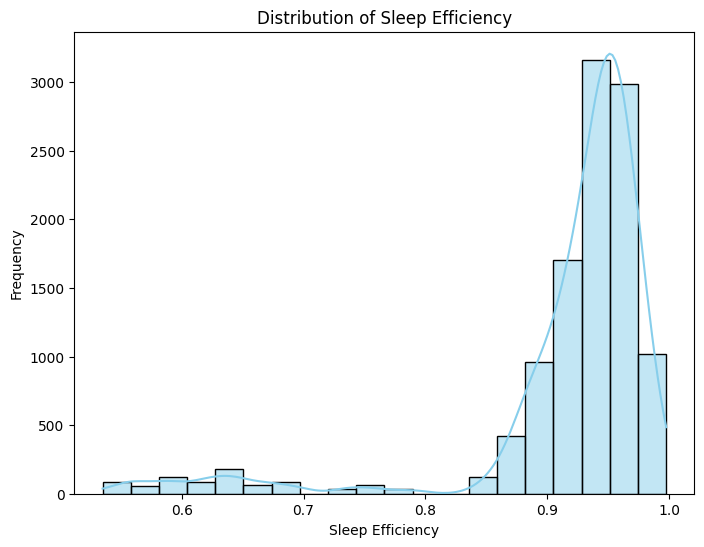

In [16]:
# Add sleep efficiency column
merged_df['SleepEfficiency'] = merged_df['TotalMinutesAsleep'] / merged_df['TotalTimeInBed']

# Check overall average
print("Average Sleep Efficiency:", merged_df['SleepEfficiency'].mean())

# Optional: Plot distribution
plt.figure(figsize=(8,6))
sns.histplot(merged_df['SleepEfficiency'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sleep Efficiency')
plt.xlabel('Sleep Efficiency')
plt.ylabel('Frequency')
plt.show()


In [17]:
merged_df.describe()

,Id_x,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Id_y,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepEfficiency
count,1.118700e+04,11187,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,11187.000000,1.118700e+04,11187.000000,11187.000000,11187.000000,11187.000000
mean,4.805031e+09,2016-04-25 18:33:57.007240448,7437.582015,5.300888,5.285843,0.108509,1.323547,0.555741,3.350483,0.001596,19.144632,13.272191,194.722088,998.382498,2294.222580,5.080323e+09,1.116564,429.174041,467.471440,0.918125
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,403.000000,1.503960e+09,1.000000,213.000000,248.000000,0.534989
25%,2.320127e+09,2016-04-19 00:00:00,3821.000000,2.650000,2.650000,0.000000,0.000000,0.000000,1.960000,0.000000,0.000000,0.000000,129.000000,732.000000,1838.000000,3.977334e+09,1.000000,377.000000,413.000000,0.912360
50%,4.445115e+09,2016-04-26 00:00:00,7359.000000,5.200000,5.200000,0.000000,0.190000,0.230000,3.380000,0.000000,3.000000,6.000000,199.000000,1058.000000,2132.000000,4.702922e+09,1.000000,433.000000,465.000000,0.943137
75%,6.962181e+09,2016-05-03 00:00:00,10602.000000,7.540000,7.540000,0.000000,1.940000,0.790000,4.780000,0.000000,30.000000,19.000000,266.000000,1233.000000,2772.000000,6.962181e+09,1.000000,488.000000,522.000000,0.960714
max,8.877689e+09,2016-05-12 00:00:00,20669.000000,18.250000,18.250000,4.942142,13.260000,6.480000,10.570000,0.110000,132.000000,143.000000,518.000000,1440.000000,4163.000000,8.792010e+09,3.000000,658.000000,689.000000,0.997763
std,2.405910e+09,NaN,4632.228673,3.459753,3.438535,0.625249,2.219935,0.866205,2.006861,0.007361,28.393118,19.698347,108.613630,291.243754,642.230996,2.061206e+09,0.338009,83.339263,79.890089,0.084841


C:\Users\TALHA COMPUTER'S\AppData\Local\Temp\ipykernel_1392\2230850669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='ActivityLevel', y='TotalMinutesAsleep', palette='viridis')


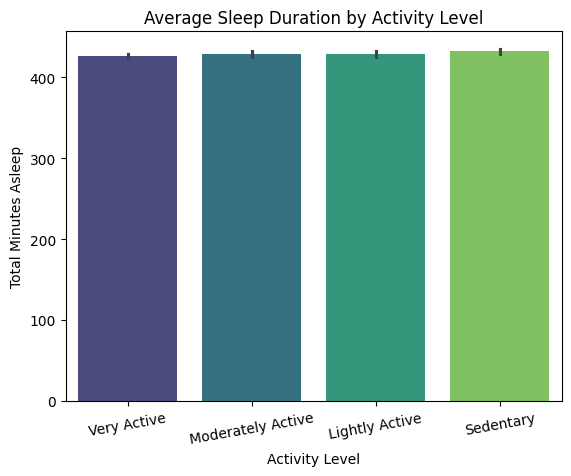

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=merged_df, x='ActivityLevel', y='TotalMinutesAsleep', palette='viridis')

plt.title("Average Sleep Duration by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Total Minutes Asleep")
plt.xticks(rotation=10)
plt.show()
